# News Dataset - Exploratory Data Analysis (EDA)

Exploratory analysis of the raw GDELT news article dataset across 20 stock tickers.

**Data source**: `gdelt_news_data/` directory  
**Columns**: `ticker, date, headline, source, url, language, sourcecountry, search_keyword`  
**Period**: October 2023 - October 2025

## 1. Imports and Data Loading

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 160

In [2]:
# Resolve data directory
BASE_DIR = Path.cwd().resolve()
if not (BASE_DIR / "Raw_Data/gdelt_news_data").exists():
    BASE_DIR = BASE_DIR.parent

INPUT_DIR = BASE_DIR / "Raw_Data/gdelt_news_data"
print(f"Data directory: {INPUT_DIR}")

# Load all news CSVs into a single DataFrame
all_files = sorted(INPUT_DIR.glob("*_news.csv"))
print(f"Found {len(all_files)} news CSV files")

dfs = []
for f in all_files:
    df = pd.read_csv(f)
    dfs.append(df)

news = pd.concat(dfs, ignore_index=True)
news["date"] = pd.to_datetime(news["date"], errors="coerce")
news["date_only"] = news["date"].dt.date

print(f"\nTotal articles loaded: {len(news):,}")
news.head()

Data directory: C:\Users\Alasteir\OneDrive - University of Greenwich\FYP\Raw_Data\gdelt_news_data
Found 20 news CSV files

Total articles loaded: 79,806


,ticker,date,headline,source,url,language,sourcecountry,search_keyword,date_only
0,AAPL,2023-09-01 01:00:00+00:00,"Broadcom Gives Downbeat Forecast , Signaling S...",finance.yahoo.com,https://finance.yahoo.com/news/broadcom-gives-...,English,United States,Apple Inc,2023-09-01
1,AAPL,2023-09-01 03:45:00+00:00,Long - Term Returns of David Einhorn Activist ...,finance.yahoo.com,https://finance.yahoo.com/news/long-term-retur...,English,United States,Apple Inc,2023-09-01
2,AAPL,2023-09-01 08:00:00+00:00,mophie Unveils Exciting Qi2 Technology Roadmap...,globenewswire.com,https://www.globenewswire.com/news-release/202...,English,United States,Apple Inc,2023-09-01
3,AAPL,2023-09-01 10:45:00+00:00,Huawei Mystery Phone Shows Wireless Speeds as ...,finance.yahoo.com,https://finance.yahoo.com/news/huawei-mystery-...,English,United States,Apple Inc,2023-09-01
4,AAPL,2023-09-01 10:45:00+00:00,Huawei Mystery Phone Mate 60 Pro Shows Wireles...,bloomberg.com,https://www.bloomberg.com/news/articles/2023-0...,English,United States,Apple Inc,2023-09-01


## 2. Dataset Overview

In [3]:
print("Shape:", news.shape)
print("\nColumn dtypes:")
print(news.dtypes)
print("\nMissing values:")
print(news.isnull().sum())
print("\nDuplicate rows:", news.duplicated().sum())

Shape: (79806, 9)

Column dtypes:
ticker                         object
date              datetime64[ns, UTC]
headline                       object
source                         object
url                            object
language                       object
sourcecountry                  object
search_keyword                 object
date_only                      object
dtype: object

Missing values:
ticker            0
date              0
headline          0
source            0
url               0
language          0
sourcecountry     6
search_keyword    0
date_only         0
dtype: int64

Duplicate rows: 0


In [4]:
news.describe(include="all")

,ticker,date,headline,source,url,language,sourcecountry,search_keyword,date_only
count,79806,79806,79806,79806,79806,79806,79800,79806,79806
unique,20,NaN,65120,71,65653,1,7,67,898
top,NVDA,NaN,5 Things to Know Before the Stock Market Opens,finance.yahoo.com,https://www.cnbc.com/2025/10/26/here-are-the-3...,English,United States,Nvidia,2025-11-17
freq,12309,NaN,18,27308,11,79806,74828,9843,318
mean,NaN,2025-02-03 18:04:30.329298944+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,2023-09-01 00:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,2024-05-11 09:26:15+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,2025-03-22 00:37:30+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,2025-11-10 04:07:30+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,2026-03-04 00:15:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Article Counts by Ticker

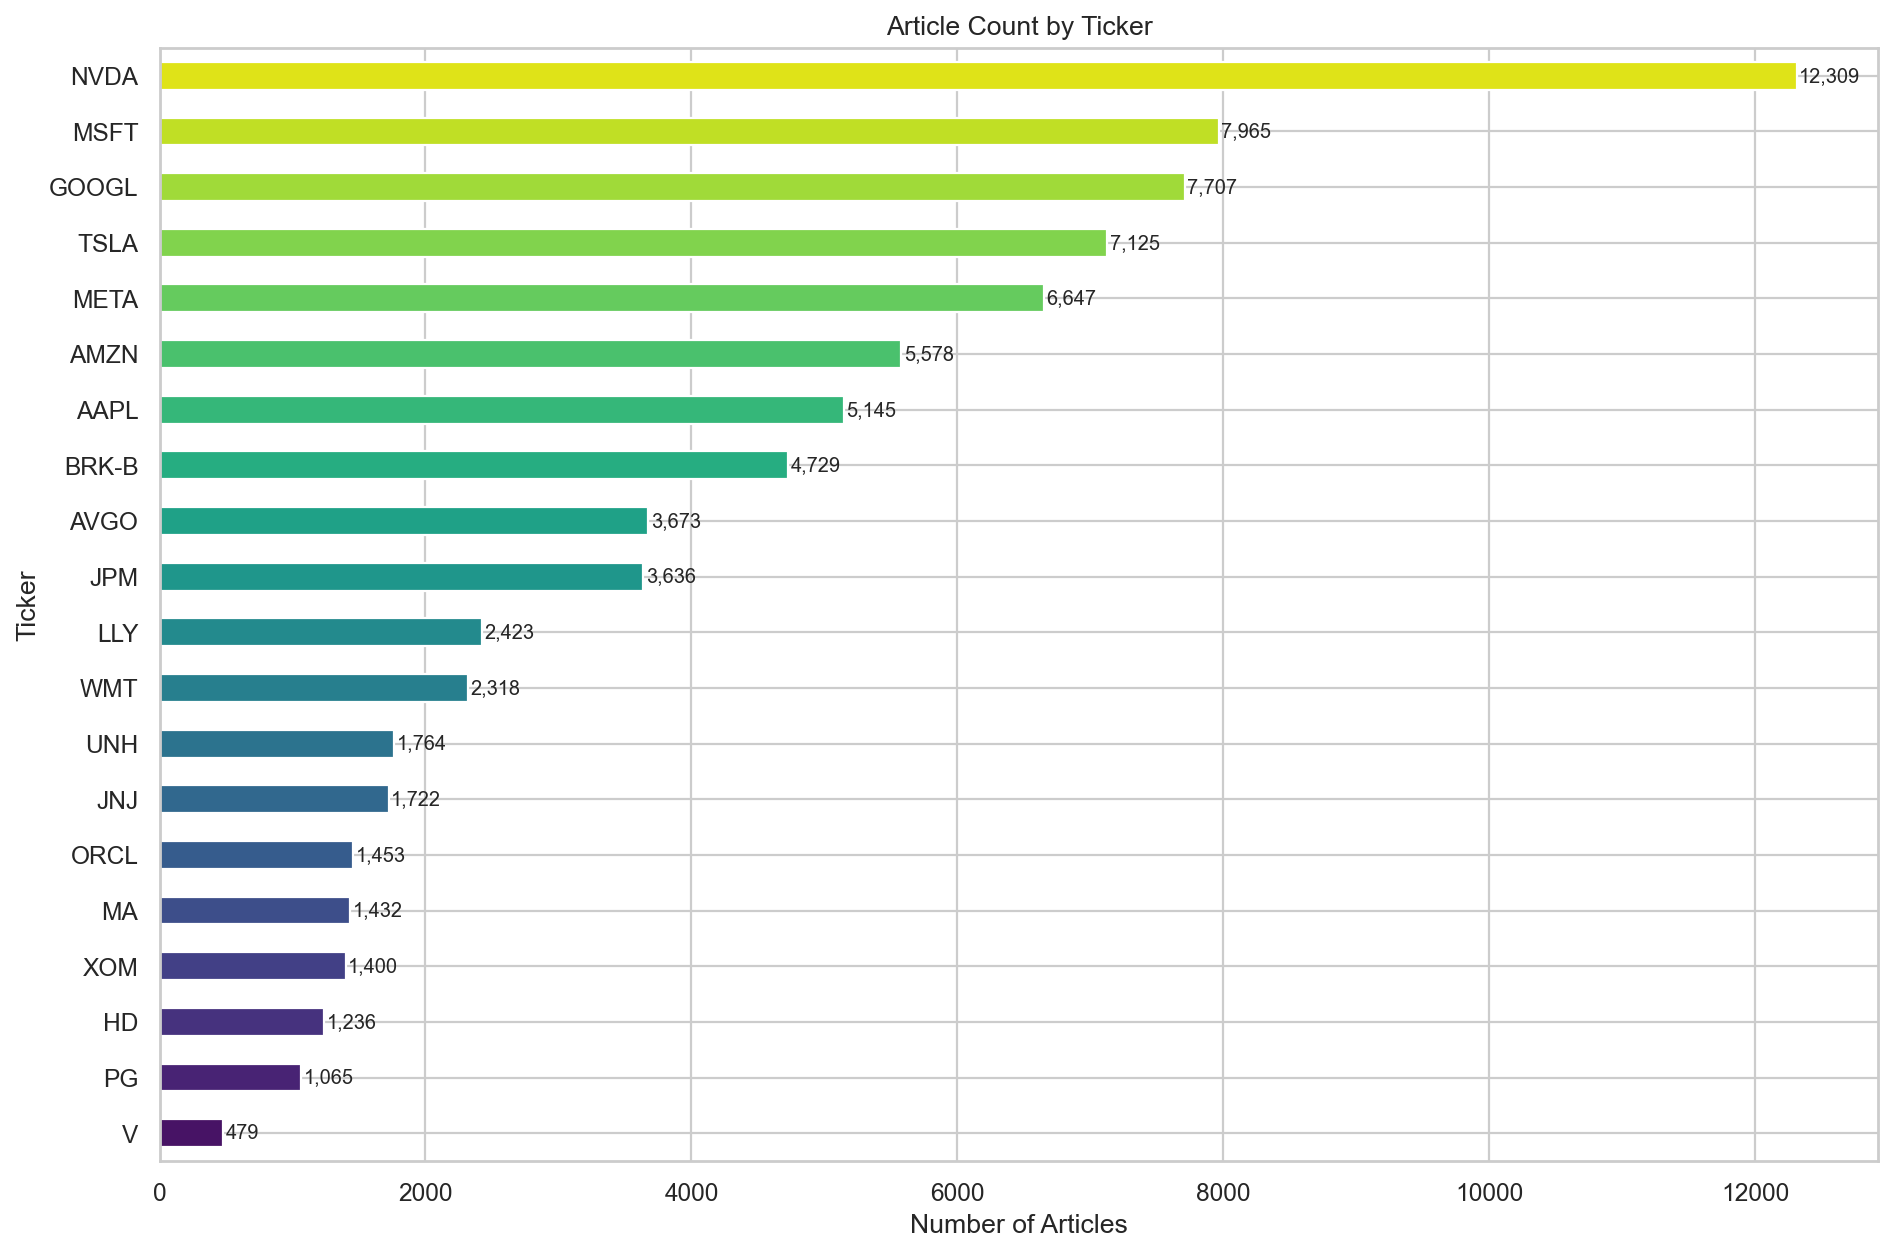


Mean: 3,990
Median: 3,030
Std Dev: 3,111


In [5]:
ticker_counts = news["ticker"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
ticker_counts.plot(kind="barh", ax=ax, color=sns.color_palette("viridis", len(ticker_counts)))
ax.set_xlabel("Number of Articles")
ax.set_ylabel("Ticker")
ax.set_title("Article Count by Ticker")

for i, v in enumerate(ticker_counts):
    ax.text(v + 20, i, f"{v:,}", va="center", fontsize=9)

plt.tight_layout()
fig.savefig(BASE_DIR / "Report" / "eda_news_by_ticker.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"\nMean: {ticker_counts.mean():,.0f}")
print(f"Median: {ticker_counts.median():,.0f}")
print(f"Std Dev: {ticker_counts.std():,.0f}")

## 4. Date Range and Temporal Coverage

In [6]:
# Date range per ticker
date_ranges = news.groupby("ticker")["date"].agg(["min", "max", "count"]).sort_values("count", ascending=False)
date_ranges.columns = ["Earliest", "Latest", "Count"]
display(date_ranges)

,Earliest,Latest,Count
ticker,,,
NVDA,2023-09-01 15:45:00+00:00,2026-03-04 00:00:00+00:00,12309
MSFT,2023-09-01 00:30:00+00:00,2026-03-03 23:45:00+00:00,7965
GOOGL,2023-09-01 02:00:00+00:00,2026-03-03 00:00:00+00:00,7707
TSLA,2023-09-01 00:30:00+00:00,2026-03-01 23:15:00+00:00,7125
META,2023-09-01 00:30:00+00:00,2026-03-04 00:15:00+00:00,6647
AMZN,2023-09-02 00:00:00+00:00,2026-03-03 00:00:00+00:00,5578
AAPL,2023-09-01 01:00:00+00:00,2026-03-03 22:00:00+00:00,5145
BRK-B,2023-09-02 11:45:00+00:00,2026-03-01 21:15:00+00:00,4729
AVGO,2023-09-01 15:30:00+00:00,2026-03-02 23:15:00+00:00,3673


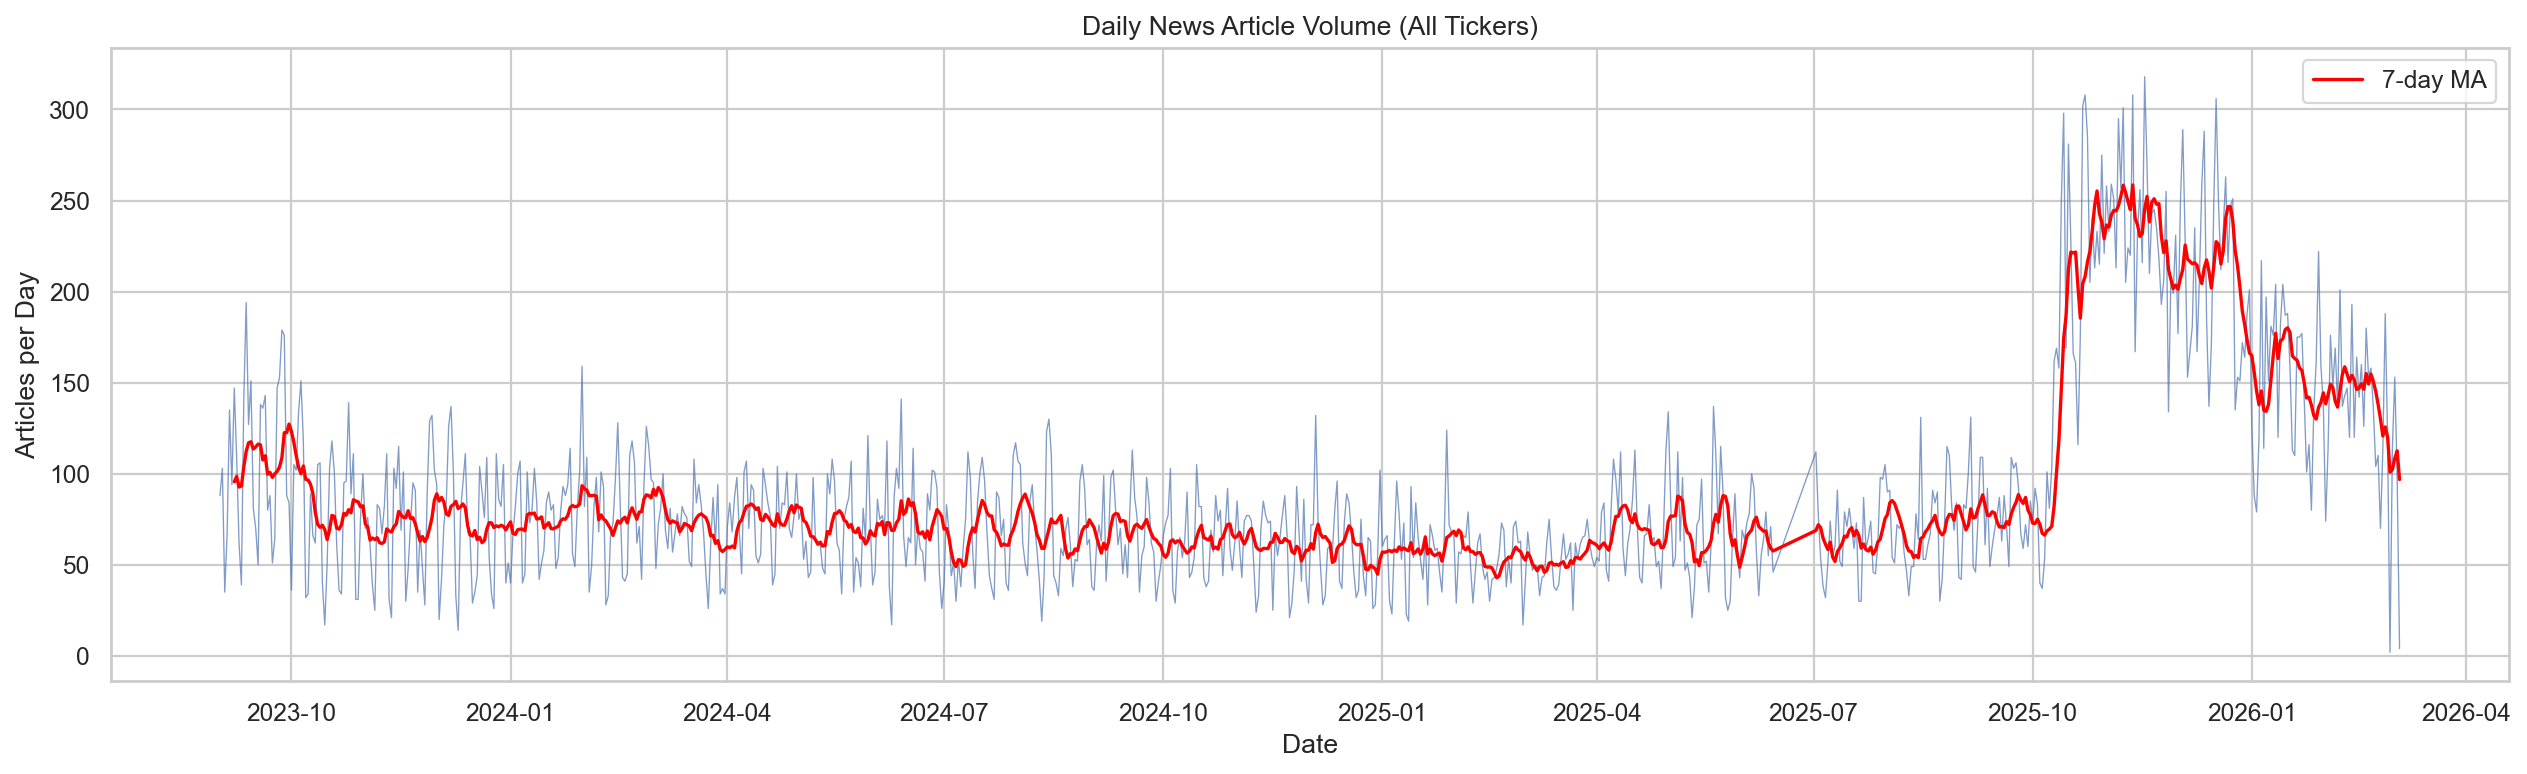

Average articles per day: 88.9
Max articles in a day: 318 (2025-11-17)
Min articles in a day: 2 (2026-02-28)


In [7]:
# Daily article volume across all tickers
daily_counts = news.groupby("date_only").size()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily_counts.index, daily_counts.values, linewidth=0.6, alpha=0.7)
ax.set_xlabel("Date")
ax.set_ylabel("Articles per Day")
ax.set_title("Daily News Article Volume (All Tickers)")

# Add 7-day rolling average
rolling = daily_counts.rolling(7).mean()
ax.plot(rolling.index, rolling.values, color="red", linewidth=1.5, label="7-day MA")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Average articles per day: {daily_counts.mean():.1f}")
print(f"Max articles in a day: {daily_counts.max()} ({daily_counts.idxmax()})")
print(f"Min articles in a day: {daily_counts.min()} ({daily_counts.idxmin()})")

C:\Users\Alasteir\AppData\Local\Temp\ipykernel_30528\2433916839.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  news["year_month"] = news["date"].dt.to_period("M")


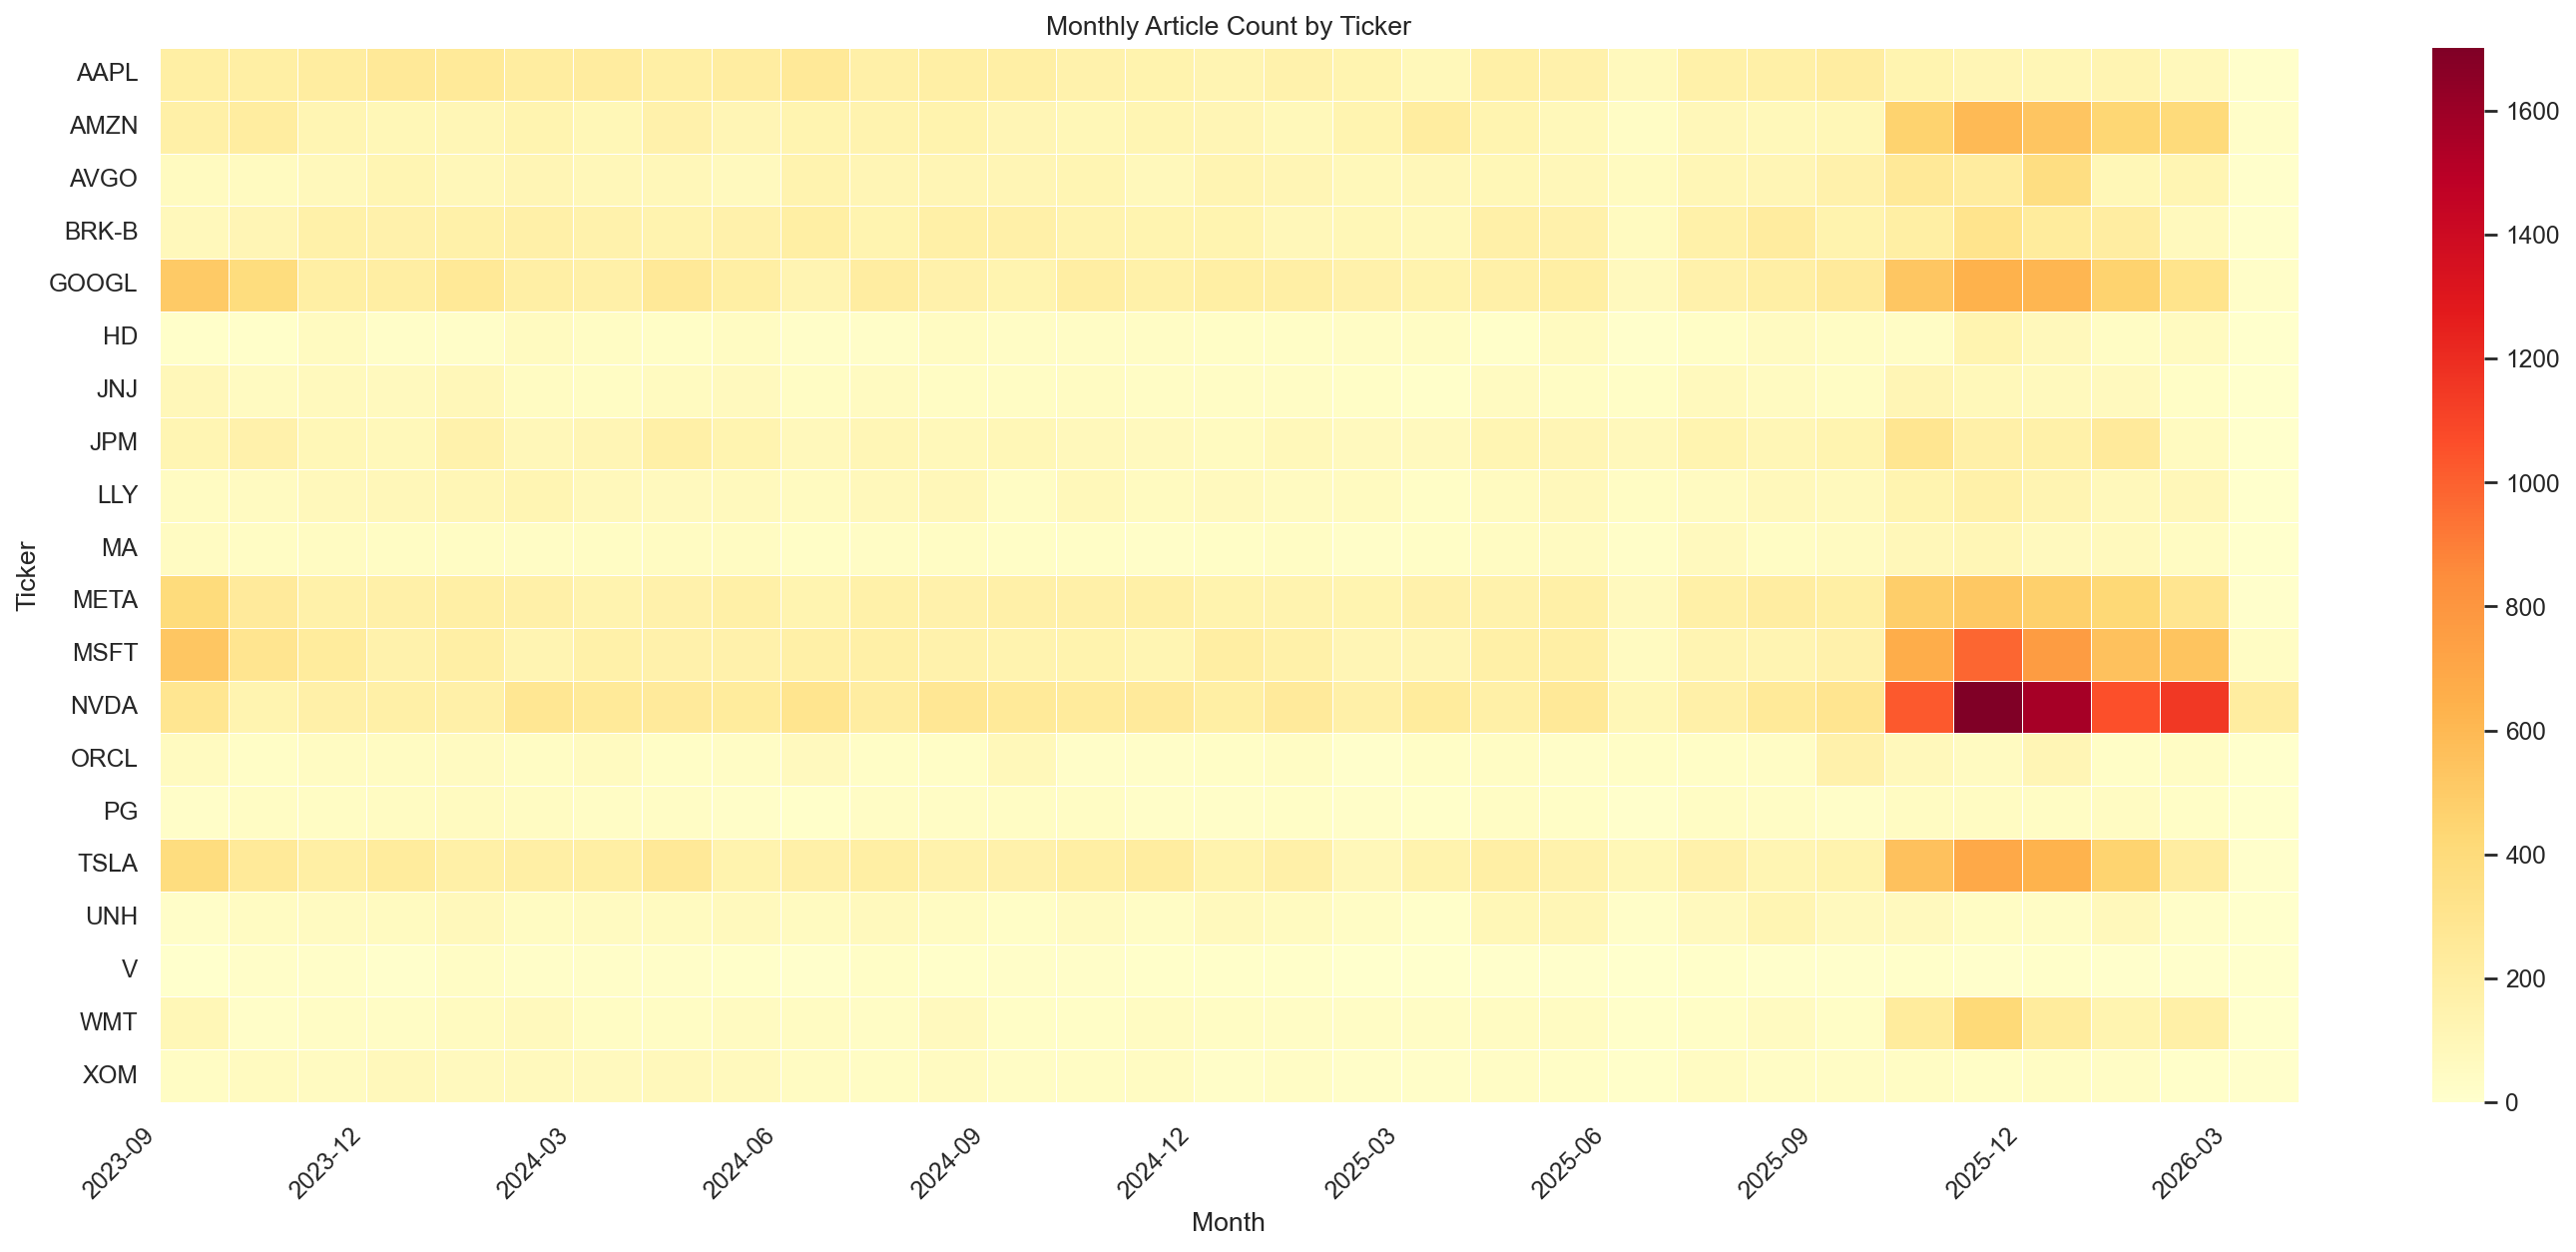

In [8]:
# Monthly article volume by ticker (heatmap)
news["year_month"] = news["date"].dt.to_period("M")
monthly_ticker = news.groupby(["year_month", "ticker"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(monthly_ticker.T, cmap="YlOrRd", ax=ax, linewidths=0.3)
ax.set_title("Monthly Article Count by Ticker")
ax.set_xlabel("Month")
ax.set_ylabel("Ticker")

# Reduce x-tick clutter
tick_positions = range(0, len(monthly_ticker.index), 3)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(monthly_ticker.index[i]) for i in tick_positions], rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 5. Source Distribution

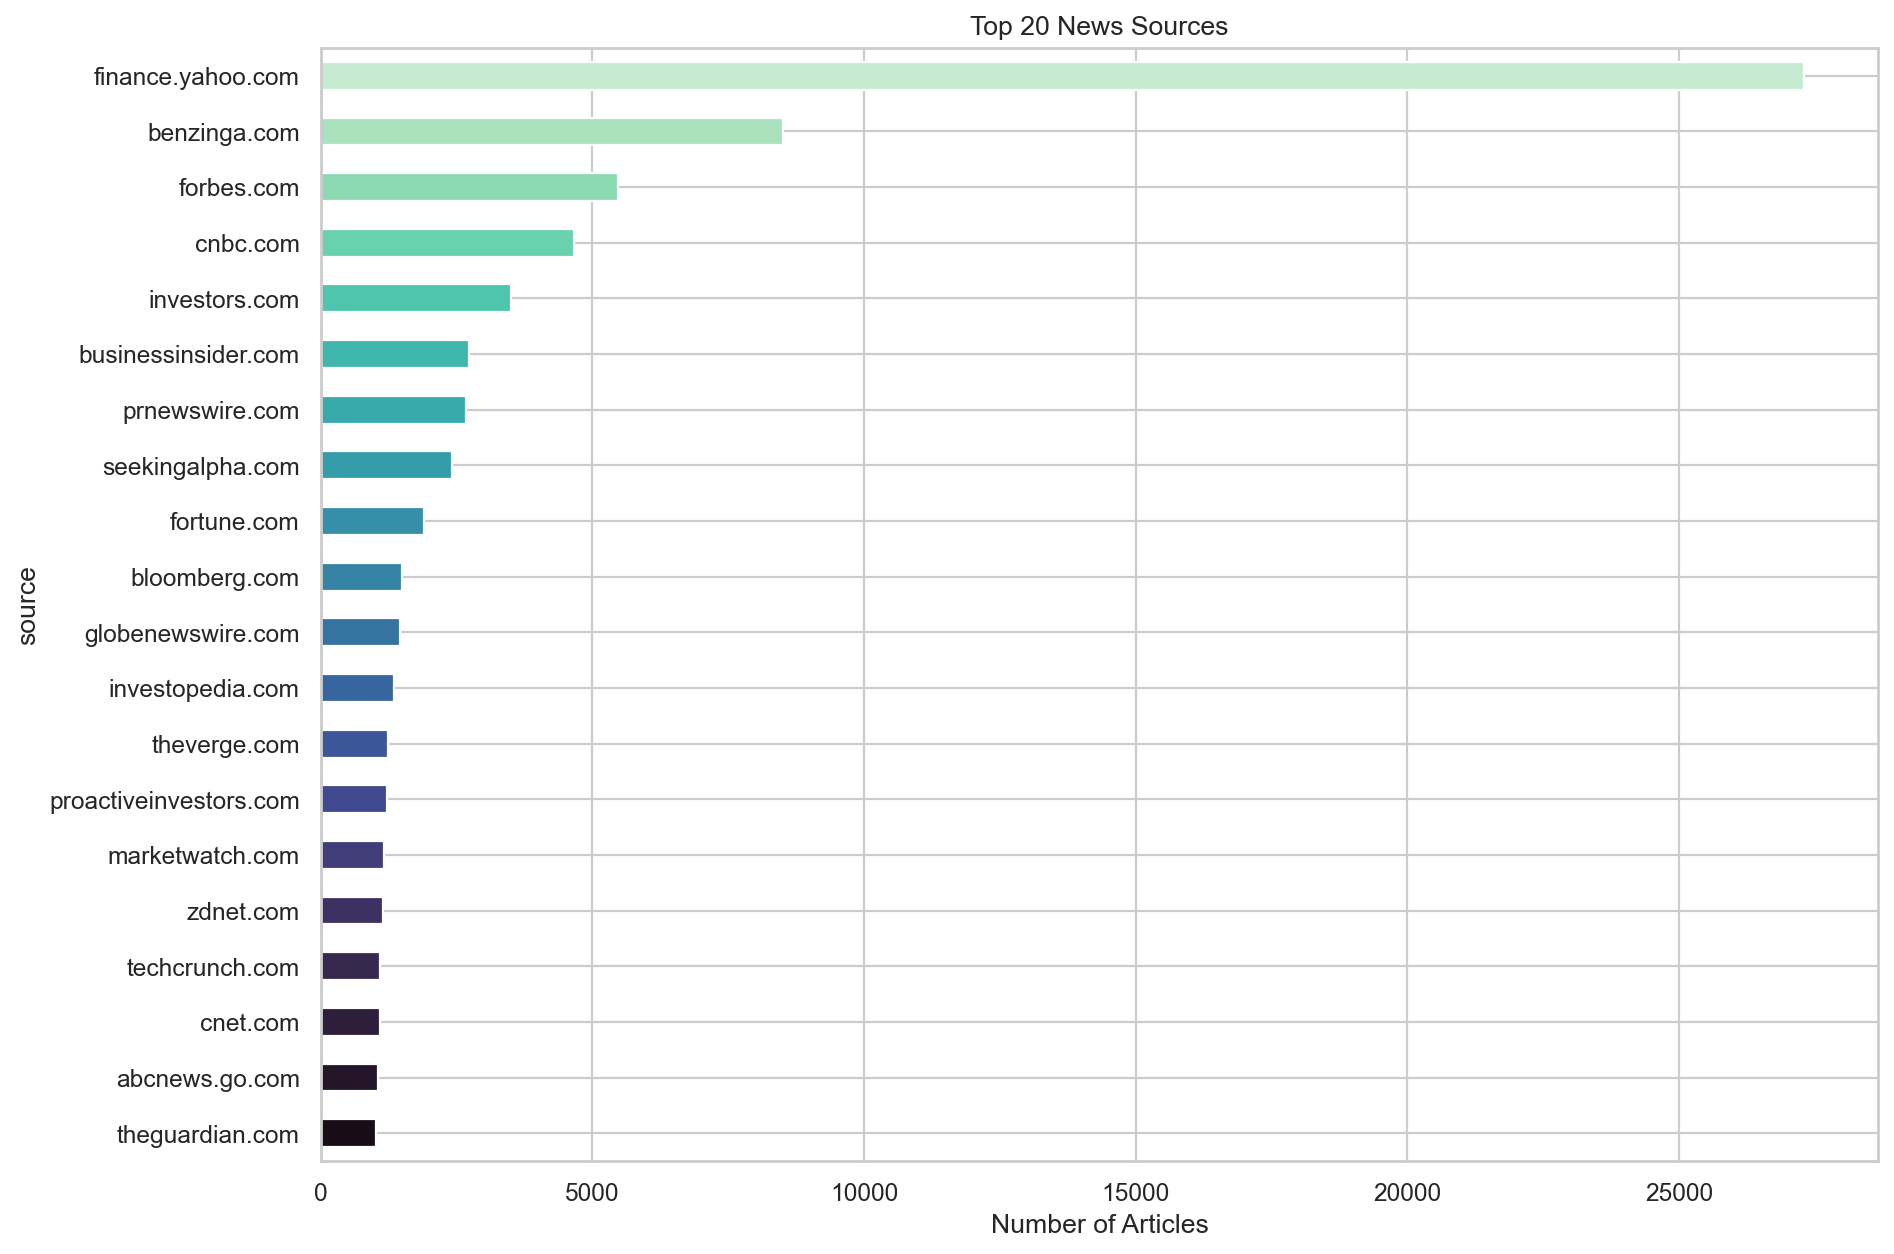


Total unique sources: 71
Top 10 sources account for 76.0% of all articles


In [9]:
# Top 20 news sources
source_counts = news["source"].value_counts()
top_sources = source_counts.head(20)

fig, ax = plt.subplots(figsize=(12, 8))
top_sources.sort_values().plot(kind="barh", ax=ax, color=sns.color_palette("mako", len(top_sources)))
ax.set_xlabel("Number of Articles")
ax.set_title("Top 20 News Sources")
plt.tight_layout()
plt.show()

print(f"\nTotal unique sources: {news['source'].nunique()}")
print(f"Top 10 sources account for {source_counts.head(10).sum() / len(news) * 100:.1f}% of all articles")

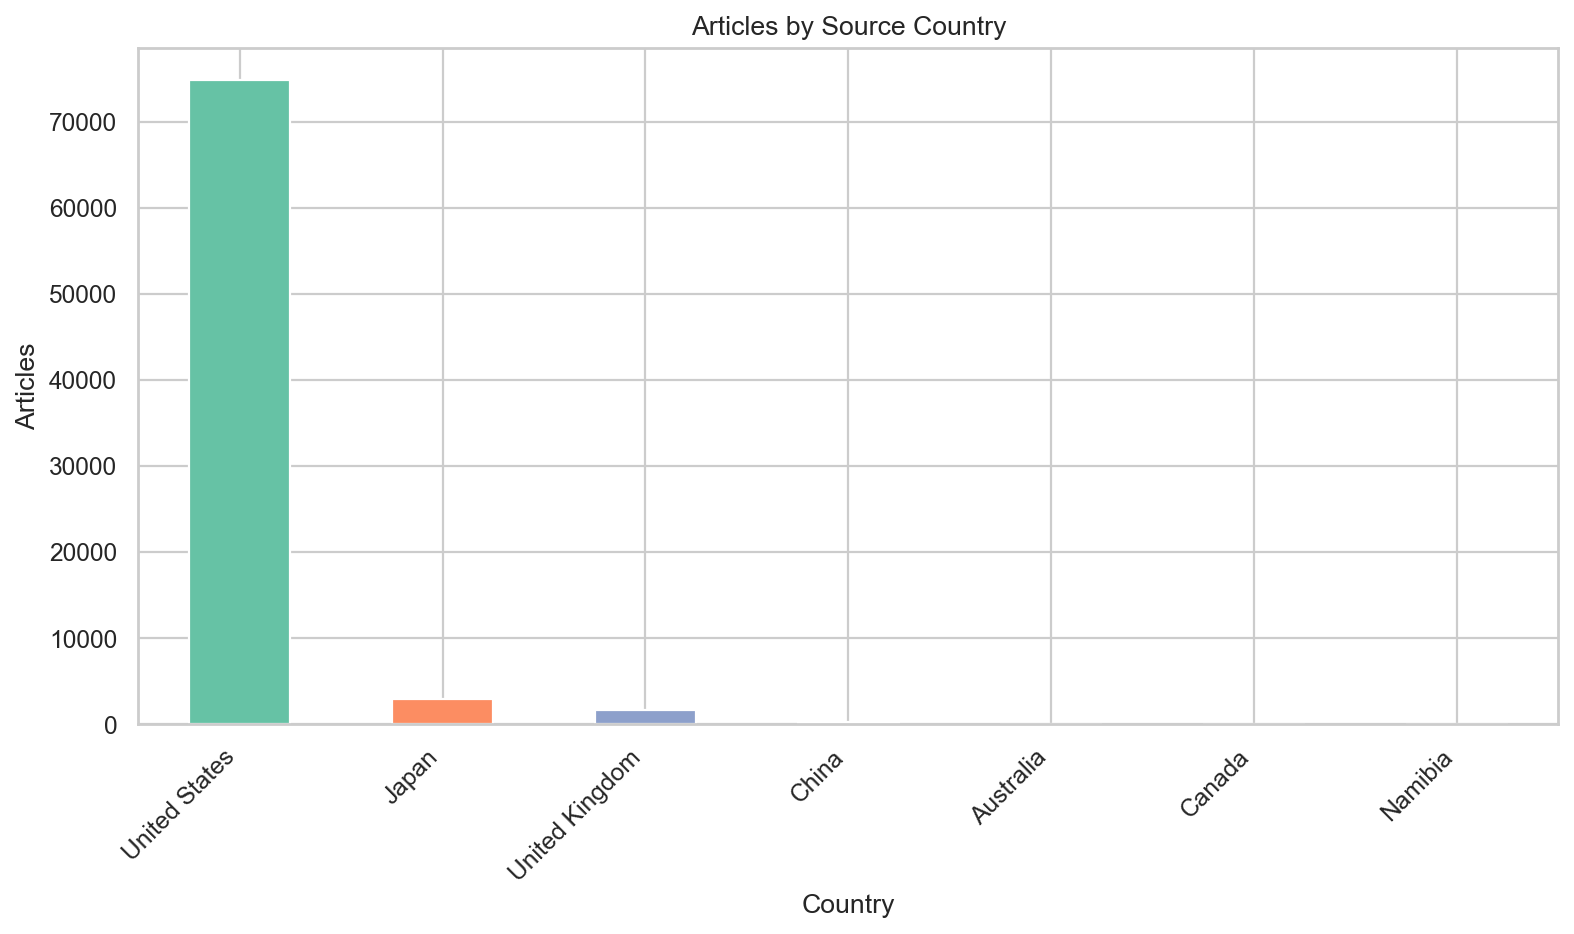

In [10]:
# Source country distribution
country_counts = news["sourcecountry"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
country_counts.plot(kind="bar", ax=ax, color=sns.color_palette("Set2"))
ax.set_xlabel("Country")
ax.set_ylabel("Articles")
ax.set_title("Articles by Source Country")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Headline Length Analysis

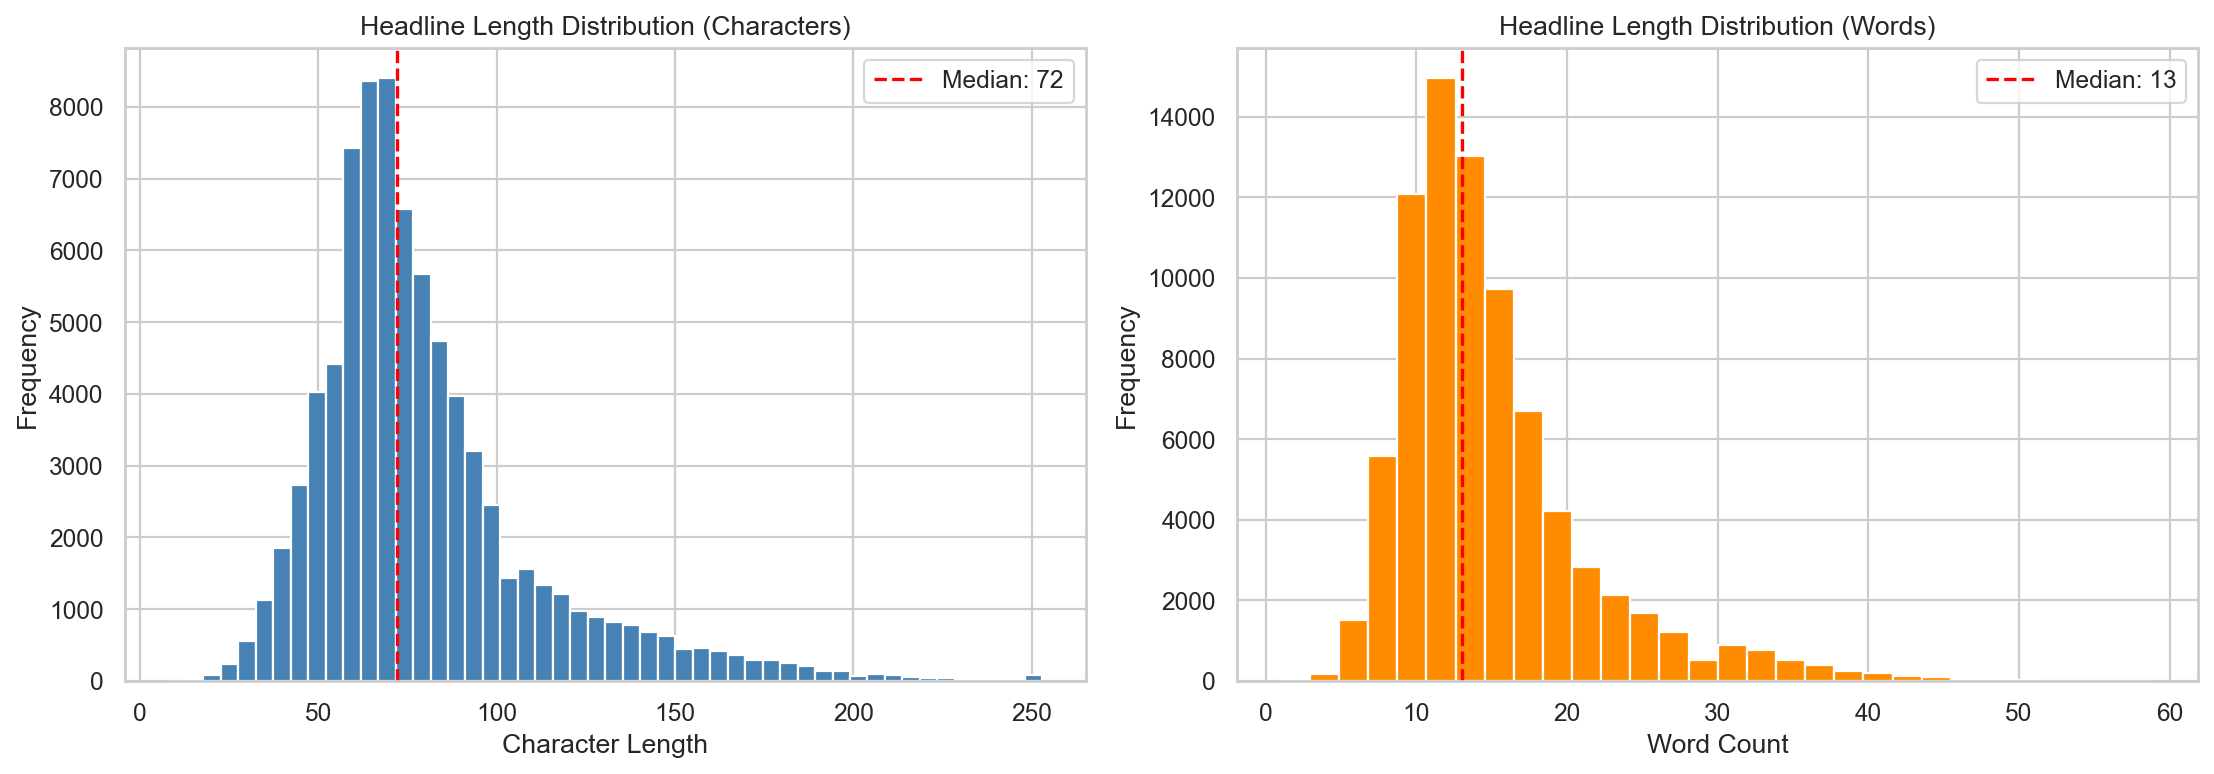

Headline character length - Mean: 79.9, Median: 72, Std: 32.0
Headline word count     - Mean: 14.9, Median: 13, Std: 6.5


In [11]:
news["headline_len"] = news["headline"].astype(str).str.len()
news["headline_word_count"] = news["headline"].astype(str).str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(news["headline_len"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Character Length")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Headline Length Distribution (Characters)")
axes[0].axvline(news["headline_len"].median(), color="red", linestyle="--", label=f"Median: {news['headline_len'].median():.0f}")
axes[0].legend()

axes[1].hist(news["headline_word_count"], bins=30, color="darkorange", edgecolor="white")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Headline Length Distribution (Words)")
axes[1].axvline(news["headline_word_count"].median(), color="red", linestyle="--", label=f"Median: {news['headline_word_count'].median():.0f}")
axes[1].legend()

plt.tight_layout()
fig.savefig(BASE_DIR / "Report" / "eda_news_headline_length.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Headline character length - Mean: {news['headline_len'].mean():.1f}, Median: {news['headline_len'].median():.0f}, Std: {news['headline_len'].std():.1f}")
print(f"Headline word count     - Mean: {news['headline_word_count'].mean():.1f}, Median: {news['headline_word_count'].median():.0f}, Std: {news['headline_word_count'].std():.1f}")

## 7. Language Distribution

In [12]:
lang_counts = news["language"].value_counts()

print("Language distribution:")
for lang, count in lang_counts.items():
    print(f"  {lang}: {count:,} ({count/len(news)*100:.1f}%)")

if len(lang_counts) > 1:
    fig, ax = plt.subplots(figsize=(8, 5))
    lang_counts.plot(kind="bar", ax=ax, color=sns.color_palette("pastel"))
    ax.set_title("Articles by Language")
    ax.set_ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

Language distribution:
  English: 79,806 (100.0%)


## 8. Duplicate and Data Quality Analysis

In [13]:
# Check for duplicate headlines
dup_headlines = news["headline"].duplicated().sum()
dup_full = news.duplicated().sum()

print(f"Duplicate headlines (same text, possibly different dates/tickers): {dup_headlines:,} ({dup_headlines/len(news)*100:.1f}%)")
print(f"Fully duplicate rows: {dup_full:,} ({dup_full/len(news)*100:.1f}%)")

# Headlines appearing across multiple tickers
headline_ticker_count = news.groupby("headline")["ticker"].nunique()
cross_ticker = headline_ticker_count[headline_ticker_count > 1]
print(f"\nHeadlines appearing for multiple tickers: {len(cross_ticker):,}")

if len(cross_ticker) > 0:
    print("\nSample of cross-ticker headlines:")
    for headline in cross_ticker.sort_values(ascending=False).head(5).index:
        tickers = news[news["headline"] == headline]["ticker"].unique()
        print(f"  [{', '.join(tickers)}] {headline[:100]}")

Duplicate headlines (same text, possibly different dates/tickers): 14,686 (18.4%)
Fully duplicate rows: 0 (0.0%)

Headlines appearing for multiple tickers: 10,367

Sample of cross-ticker headlines:
  [AAPL, AMZN, AVGO, BRK-B, GOOGL, HD, JNJ, JPM, LLY, MA, META, MSFT, NVDA, ORCL, PG, TSLA, UNH, WMT] 5 Things to Know Before the Stock Market Opens
  [AMZN, AVGO, BRK-B, HD, JNJ, JPM, LLY, MA, META, MSFT, NVDA, ORCL, PG, TSLA, UNH, WMT, XOM] Stock market today : Live updates
  [AAPL, AMZN, AVGO, BRK-B, HD, JNJ, JPM, LLY, MA, META, MSFT, NVDA, PG, TSLA, UNH] What To Expect in the Markets This Week
  [AAPL, AMZN, AVGO, GOOGL, HD, LLY, MA, META, MSFT, NVDA, UNH, V, WMT, XOM] Here are the 3 big things were watching in the stock market this week
  [AAPL, AVGO, BRK-B, GOOGL, HD, JNJ, LLY, MA, META, NVDA, ORCL, PG, UNH, WMT] Jim Cramer top 10 things to watch in the stock market Wednesday


## 9. Day-of-Week Distribution

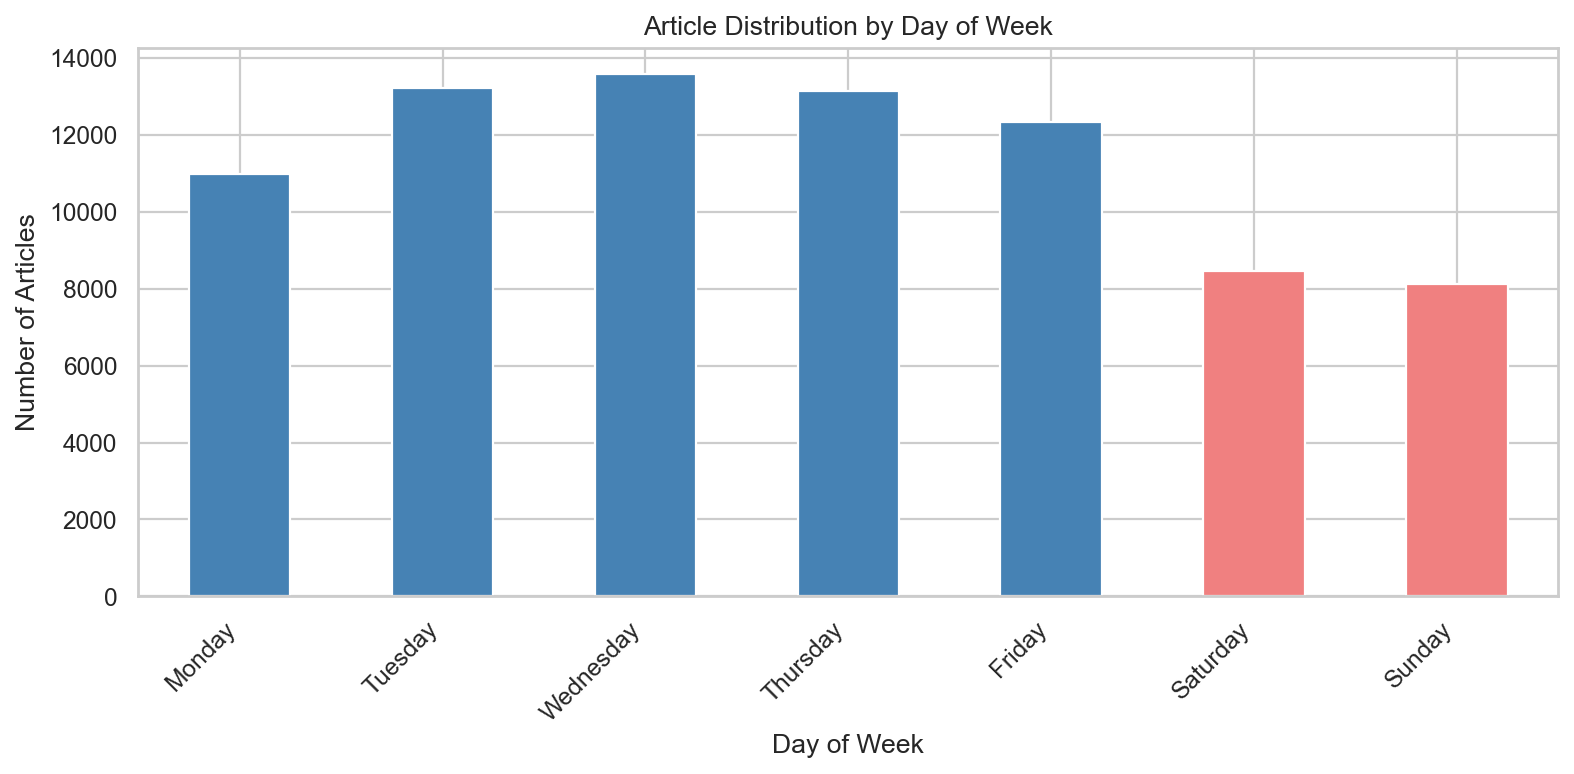

Weekday articles: 63,235 (79.2%)
Weekend articles: 16,571 (20.8%)


In [14]:
news["day_of_week"] = news["date"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_counts = news["day_of_week"].value_counts().reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 5))
dow_counts.plot(kind="bar", ax=ax, color=["steelblue"]*5 + ["lightcoral"]*2)
ax.set_xlabel("Day of Week")
ax.set_ylabel("Number of Articles")
ax.set_title("Article Distribution by Day of Week")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

weekday = dow_counts[:5].sum()
weekend = dow_counts[5:].sum()
print(f"Weekday articles: {weekday:,} ({weekday/len(news)*100:.1f}%)")
print(f"Weekend articles: {weekend:,} ({weekend/len(news)*100:.1f}%)")

## 9.5 UTC-to-NYSE Session Assignment EDA

Analyses how the 16:00 ET market-close cutoff distributes news articles across sessions.

- **Article volume by ET hour** — shows publication patterns relative to the 16:00 ET cutoff
- **Same vs next session split** — overall and per-ticker breakdown of reassignments
- **Day-of-week distribution (ET)** — weekend articles are always pushed to Monday's session

Total articles (raw):                      79,806
At/before 16:00 ET -> same session:        54,940 (68.8%)
After 16:00 ET     -> next session:        24,866 (31.2%)
Published on weekends (ET, pushed to Mon): 15,429 (19.3%)


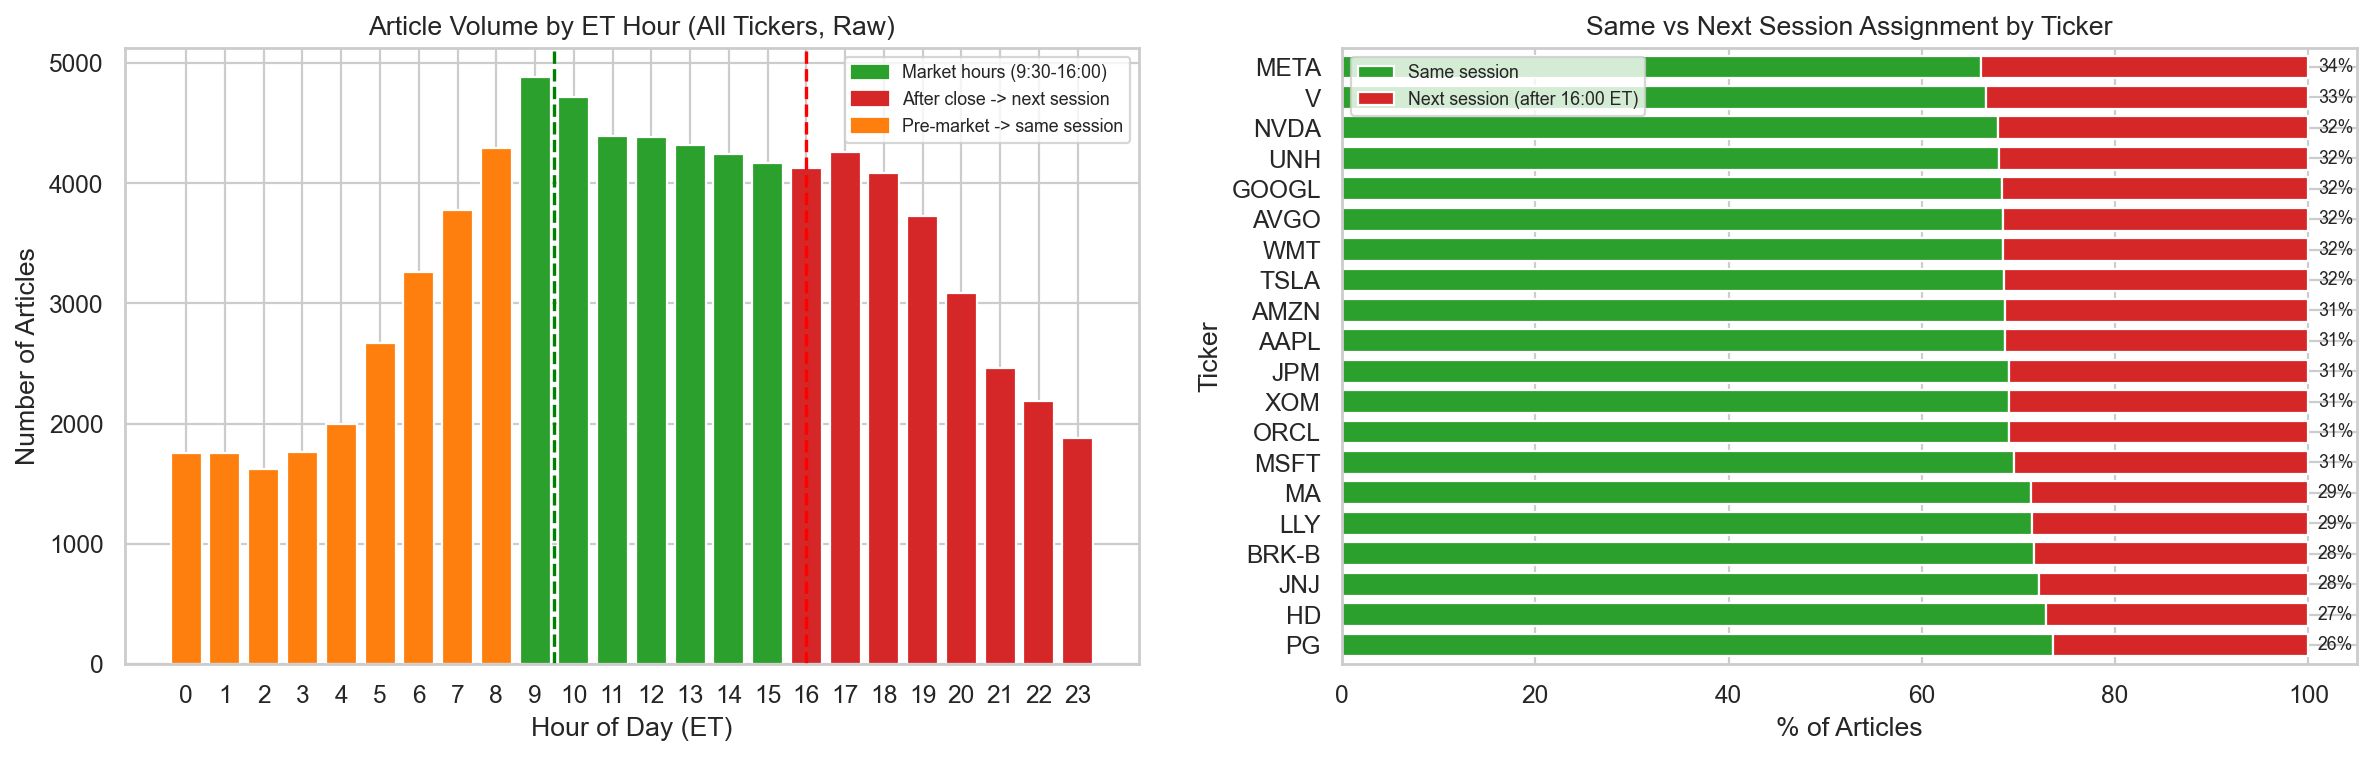

In [15]:
import matplotlib.patches as mpatches

# news["date"] is already datetime64[us, UTC] — convert to ET
news["date_et"] = news["date"].dt.tz_convert("America/New_York")

sec = (
    news["date_et"].dt.hour * 3600
    + news["date_et"].dt.minute * 60
    + news["date_et"].dt.second
)
news["after_close"] = sec > 16 * 3600
news["hour_et"] = news["date_et"].dt.hour
news["day_of_week_et"] = news["date_et"].dt.day_name()

total = len(news)
n_after = news["after_close"].sum()
n_before = total - n_after

print(f"Total articles (raw):                      {total:,}")
print(f"At/before 16:00 ET -> same session:        {n_before:,} ({n_before/total*100:.1f}%)")
print(f"After 16:00 ET     -> next session:        {n_after:,} ({n_after/total*100:.1f}%)")

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow = news["day_of_week_et"].value_counts().reindex(day_order).fillna(0).astype(int)
weekend_n = int(dow[["Saturday", "Sunday"]].sum())
print(f"Published on weekends (ET, pushed to Mon): {weekend_n:,} ({weekend_n/total*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Plot 1: ET hour distribution 
hour_counts = news["hour_et"].value_counts().sort_index()

def hour_color(h):
    if 9 <= h < 16:
        return "#2ca02c"
    elif h >= 16:
        return "#d62728"
    else:
        return "#ff7f0e"

colors = [hour_color(h) for h in hour_counts.index]
axes[0].bar(hour_counts.index, hour_counts.values, color=colors, edgecolor="white", width=0.8)
axes[0].axvline(9.5, color="green", linestyle="--", linewidth=1.5)
axes[0].axvline(16,  color="red",   linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Hour of Day (ET)")
axes[0].set_ylabel("Number of Articles")
axes[0].set_title("Article Volume by ET Hour (All Tickers, Raw)")
axes[0].set_xticks(range(0, 24))
patch_mkt  = mpatches.Patch(color="#2ca02c", label="Market hours (9:30-16:00)")
patch_post = mpatches.Patch(color="#d62728", label="After close -> next session")
patch_pre  = mpatches.Patch(color="#ff7f0e", label="Pre-market -> same session")
axes[0].legend(handles=[patch_mkt, patch_post, patch_pre], fontsize=8)

# Plot 2: Same vs next session by ticker
ticker_split = (
    news.groupby("ticker")["after_close"]
    .agg(after_close_n="sum", total="count")
    .assign(
        same_pct=lambda d: (d["total"] - d["after_close_n"]) / d["total"] * 100,
        next_pct=lambda d: d["after_close_n"] / d["total"] * 100,
    )
    .sort_values("next_pct")
)
ticker_split[["same_pct", "next_pct"]].plot(
    kind="barh", stacked=True, ax=axes[1],
    color=["#2ca02c", "#d62728"], width=0.75,
)
axes[1].set_xlabel("% of Articles")
axes[1].set_ylabel("Ticker")
axes[1].set_title("Same vs Next Session Assignment by Ticker")
axes[1].legend(["Same session", "Next session (after 16:00 ET)"], fontsize=8)
axes[1].set_xlim(0, 105)
for i, (_, row) in enumerate(ticker_split.iterrows()):
    axes[1].text(101, i, f"{row['next_pct']:.0f}%", va="center", fontsize=8)

## 10. Summary

In [16]:
print("=" * 60)
print("NEWS DATASET EDA SUMMARY")
print("=" * 60)
print(f"Total articles:          {len(news):,}")
print(f"Tickers:                 {news['ticker'].nunique()}")
print(f"Date range:              {news['date'].min().strftime('%Y-%m-%d')} to {news['date'].max().strftime('%Y-%m-%d')}")
print(f"Unique sources:          {news['source'].nunique():,}")
print(f"Languages:               {news['language'].nunique()}")
print(f"Missing headlines:       {news['headline'].isna().sum():,}")
print(f"Duplicate rows:          {news.duplicated().sum():,}")
print(f"Avg headline length:     {news['headline_len'].mean():.0f} chars / {news['headline_word_count'].mean():.0f} words")
print(f"Avg articles per day:    {daily_counts.mean():.1f}")
print("=" * 60)

NEWS DATASET EDA SUMMARY
Total articles:          79,806
Tickers:                 20
Date range:              2023-09-01 to 2026-03-04
Unique sources:          71
Languages:               1
Missing headlines:       0
Duplicate rows:          0
Avg headline length:     80 chars / 15 words
Avg articles per day:    88.9
